# Cosmos 3 Nano Reasoner × MMAD — Pilot Analysis (Questions 1–230)

This notebook evaluates the first 230 MMAD question records attempted through the NVIDIA Build Experience UI.

**Evaluation policy**

- The unit of evaluation is a MMAD question, not an image.
- If a question was retried, only its latest record is used.
- `conditional accuracy` evaluates questions with a parsed A/B/C/D answer.
- `effective accuracy` counts missing outputs as incorrect and therefore measures end-to-end benchmark utility.
- Service failures are reported separately from model errors.
- Results after question 230 are excluded because the endpoint entered a persistent no-output state.

This is a **pilot**, not a valid full-MMAD score.

In [1]:
from pathlib import Path
import json, math, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path.cwd()
candidates = []
for base in [ROOT, *ROOT.parents]:
    direct = base / 'research/mmad_model_benchmark/outputs/cosmos3_full/predictions.jsonl'
    if direct.exists():
        candidates.append(direct)
if not candidates:
    candidates = list(ROOT.rglob('predictions.jsonl'))
    candidates = [p for p in candidates if 'cosmos3_full' in p.parts]
if not candidates:
    raise FileNotFoundError('Could not find Cosmos 3 predictions.jsonl')
PREDICTIONS = candidates[0]

raw_rows = [json.loads(line) for line in PREDICTIONS.read_text(encoding='utf-8').splitlines() if line.strip()]
for line_no, row in enumerate(raw_rows, 1):
    row['_line_no'] = line_no
    row['question_index'] = int(row['sample_id'].rsplit('_', 1)[1])

scope_attempts = [r for r in raw_rows if r['question_index'] <= 230]
latest = {}
attempt_counts = Counter()
for row in scope_attempts:
    latest[row['question_index']] = row
    attempt_counts[row['question_index']] += 1

records = [latest[i] for i in sorted(latest)]
df = pd.json_normalize(records, sep='.')
df['attempt_count'] = df['question_index'].map(attempt_counts)
df['has_answer'] = df['prediction'].isin(list('ABCD'))
df['correct'] = df['has_answer'] & (df['prediction'] == df['ground_truth'])
df['service_success'] = df['status'].eq('ok')
df['answer_length'] = df.get('reasoning_chars', 0).fillna(0) + df.get('response_chars', 0).fillna(0)

print('Source:', PREDICTIONS)
print(f'Raw JSONL rows: {len(raw_rows):,}')
print(f'Rows inside pilot scope including retries: {len(scope_attempts):,}')
print(f'Unique latest question records: {len(df):,}')
assert len(df) == 230, f'Expected 230 unique questions, found {len(df)}'

Source: C:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision\research\mmad_model_benchmark\outputs\cosmos3_full\predictions.jsonl
Raw JSONL rows: 1,310
Rows inside pilot scope including retries: 249
Unique latest question records: 230


## 1. Data integrity and retry audit

This section verifies that retries do not inflate the score. The latest-record policy mirrors how the resumable runner behaves operationally.

In [2]:
audit = pd.DataFrame({
    'item': [
        'Unique questions in scope', 'Total attempts in scope', 'Questions retried',
        'Extra retry rows', 'First question index', 'Last question index',
        'Manifest hashes observed'
    ],
    'value': [
        len(df), len(scope_attempts), int((df['attempt_count'] > 1).sum()),
        len(scope_attempts) - len(df), int(df.question_index.min()), int(df.question_index.max()),
        int(df.manifest_sha256.nunique())
    ]
})
display(audit)

retry_dist = df['attempt_count'].value_counts().sort_index().rename_axis('attempts').reset_index(name='questions')
display(retry_dist)
assert df.manifest_sha256.nunique() == 1, 'Mixed benchmark manifests detected'

,item,value
0,Unique questions in scope,230
1,Total attempts in scope,249
2,Questions retried,14
3,Extra retry rows,19
4,First question index,1
5,Last question index,230
6,Manifest hashes observed,1


,attempts,questions
0,1,216
1,2,12
2,4,1
3,5,1


## 2. Endpoint coverage and benchmark accuracy

Accuracy is reported in two forms so that a model failure and a serving failure are not conflated.

,metric,value
0,Questions,230.000
1,Parsed answers,221.000
2,Coverage,0.961
3,Correct parsed answers,110.000
4,Conditional accuracy,0.498
5,Effective accuracy,0.478


Coverage 95% Wilson CI: 92.7%–97.9%
Conditional accuracy 95% Wilson CI: 43.2%–56.3%
Binary random-choice baseline: 50.0%


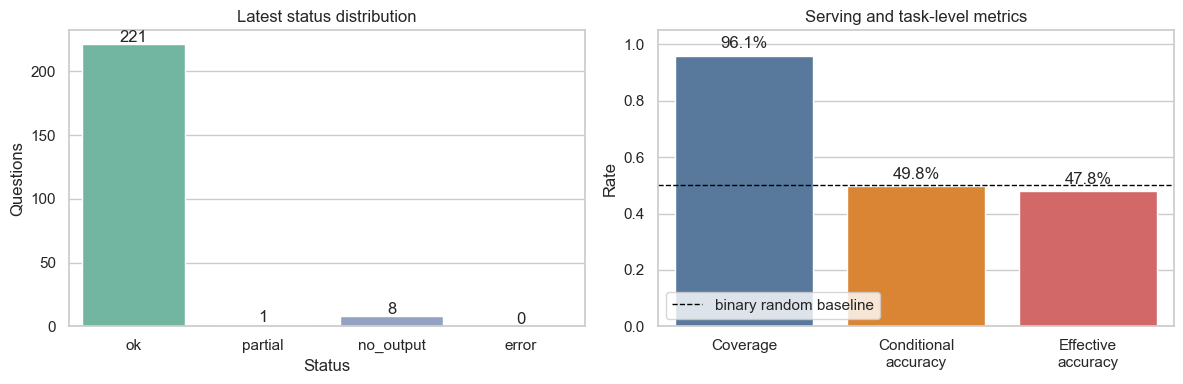

In [3]:
def wilson_interval(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z*z/n
    center = (p + z*z/(2*n)) / den
    half = z * math.sqrt((p*(1-p) + z*z/(4*n))/n) / den
    return center-half, center+half

n = len(df)
answered = int(df.has_answer.sum())
correct = int(df.correct.sum())
coverage = answered / n
conditional_accuracy = correct / answered
effective_accuracy = correct / n
coverage_ci = wilson_interval(answered, n)
accuracy_ci = wilson_interval(correct, answered)

summary = pd.DataFrame({
    'metric': ['Questions', 'Parsed answers', 'Coverage', 'Correct parsed answers',
               'Conditional accuracy', 'Effective accuracy'],
    'value': [n, answered, coverage, correct, conditional_accuracy, effective_accuracy]
})
display(summary.style.format({'value': lambda x: f'{x:.3f}' if isinstance(x, float) else str(x)}))
print(f'Coverage 95% Wilson CI: {coverage_ci[0]:.1%}–{coverage_ci[1]:.1%}')
print(f'Conditional accuracy 95% Wilson CI: {accuracy_ci[0]:.1%}–{accuracy_ci[1]:.1%}')
print('Binary random-choice baseline: 50.0%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
status_order = ['ok', 'partial', 'no_output', 'error']
status_counts = df.status.value_counts().reindex(status_order, fill_value=0)
sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[0], palette='Set2')
axes[0].set(title='Latest status distribution', xlabel='Status', ylabel='Questions')
for i, v in enumerate(status_counts.values): axes[0].text(i, v + 2, str(v), ha='center')

metric_names = ['Coverage', 'Conditional\naccuracy', 'Effective\naccuracy']
metric_values = [coverage, conditional_accuracy, effective_accuracy]
sns.barplot(x=metric_names, y=metric_values, ax=axes[1], palette=['#4C78A8','#F58518','#E45756'])
axes[1].axhline(.5, color='black', linestyle='--', linewidth=1, label='binary random baseline')
axes[1].set_ylim(0, 1.05); axes[1].set(ylabel='Rate', title='Serving and task-level metrics')
axes[1].legend(loc='lower left')
for i, v in enumerate(metric_values): axes[1].text(i, v + .025, f'{v:.1%}', ha='center')
plt.tight_layout(); plt.show()

## 3. Ground-truth balance, prediction bias and confusion matrix

Missing outputs are shown as an explicit abstention class. This prevents endpoint silence from disappearing from the evaluation.

,ground_truth,prediction
A,118,122
B,112,99
NO_OUTPUT,0,9


prediction,A,B,NO_OUTPUT
ground_truth,,,
A,62,51,5
B,60,48,4


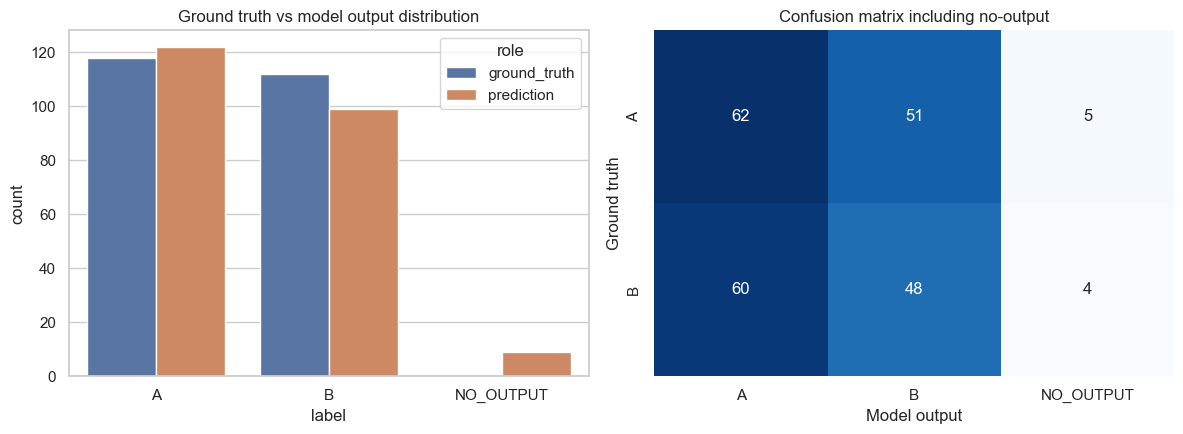

In [4]:
distribution = pd.concat([
    df.ground_truth.value_counts().rename('ground_truth'),
    df.prediction.fillna('NO_OUTPUT').value_counts().rename('prediction')
], axis=1).fillna(0).astype(int)
display(distribution)

labels = ['A', 'B', 'NO_OUTPUT']
cm = pd.crosstab(df.ground_truth, df.prediction.fillna('NO_OUTPUT')).reindex(index=['A','B'], columns=labels, fill_value=0)
display(cm)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
dist_plot = distribution.reset_index(names='label').melt('label', var_name='role', value_name='count')
sns.barplot(data=dist_plot, x='label', y='count', hue='role', ax=axes[0])
axes[0].set_title('Ground truth vs model output distribution')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Confusion matrix including no-output'); axes[1].set_xlabel('Model output'); axes[1].set_ylabel('Ground truth')
plt.tight_layout(); plt.show()

## 4. Capability slices: source, object category and normal/anomalous state

Small slices must be interpreted with their sample count and coverage. The benchmark segment contains only MVTec-AD `bottle` and `cable`, so it cannot establish general MMAD capability.

,source_dataset,category,n,answered,coverage,conditional_accuracy,effective_accuracy,mean_latency_s
0,MVTec-AD,bottle,83,81,97.6%,66.7%,65.1%,42.91
1,MVTec-AD,cable,147,140,95.2%,40.0%,38.1%,8.54


,is_normal,n,answered,coverage,conditional_accuracy,effective_accuracy,mean_latency_s
0,False,152,146,96.1%,25.3%,24.3%,27.50
1,True,78,75,96.2%,97.3%,93.6%,8.15


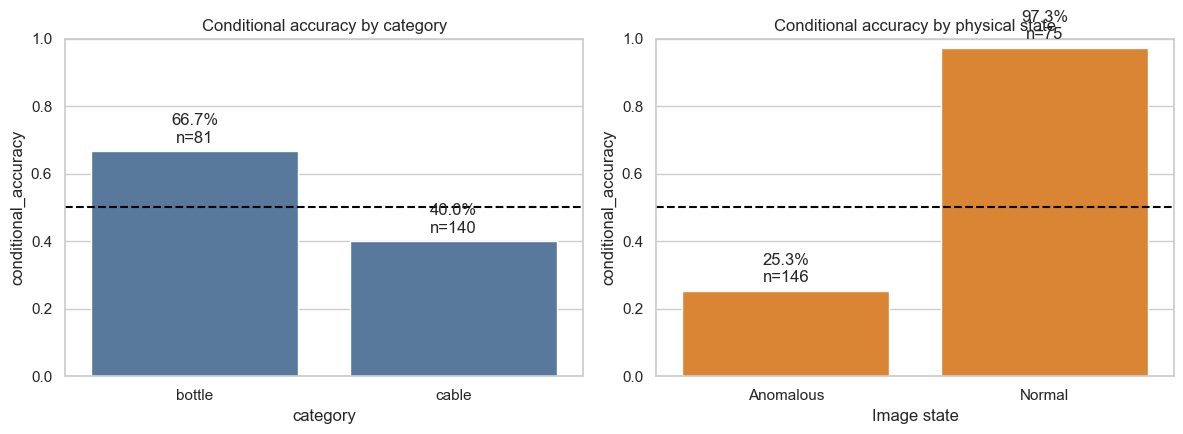

In [5]:
def slice_metrics(frame, keys):
    rows = []
    for name, group in frame.groupby(keys, dropna=False):
        if not isinstance(name, tuple): name = (name,)
        answered_g = int(group.has_answer.sum())
        correct_g = int(group.correct.sum())
        rows.append({**dict(zip(keys, name)), 'n': len(group), 'answered': answered_g,
                     'coverage': answered_g/len(group),
                     'conditional_accuracy': correct_g/answered_g if answered_g else np.nan,
                     'effective_accuracy': correct_g/len(group),
                     'mean_latency_s': group.latency_seconds.mean()})
    return pd.DataFrame(rows)

category_metrics = slice_metrics(df, ['source_dataset', 'category'])
state_metrics = slice_metrics(df, ['is_normal'])
display(category_metrics.style.format({'coverage':'{:.1%}', 'conditional_accuracy':'{:.1%}',
                                       'effective_accuracy':'{:.1%}', 'mean_latency_s':'{:.2f}'}))
display(state_metrics.style.format({'coverage':'{:.1%}', 'conditional_accuracy':'{:.1%}',
                                    'effective_accuracy':'{:.1%}', 'mean_latency_s':'{:.2f}'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=category_metrics, x='category', y='conditional_accuracy', ax=axes[0], color='#4C78A8')
axes[0].axhline(.5, color='black', linestyle='--'); axes[0].set_ylim(0,1)
axes[0].set_title('Conditional accuracy by category')
for i, r in category_metrics.reset_index(drop=True).iterrows():
    axes[0].text(i, r.conditional_accuracy+.025, f'{r.conditional_accuracy:.1%}\nn={r.answered}', ha='center')

sns.barplot(data=state_metrics, x=state_metrics.is_normal.map({True:'Normal',False:'Anomalous'}),
            y='conditional_accuracy', ax=axes[1], color='#F58518')
axes[1].axhline(.5, color='black', linestyle='--'); axes[1].set_ylim(0,1)
axes[1].set_title('Conditional accuracy by physical state'); axes[1].set_xlabel('Image state')
for i, r in state_metrics.reset_index(drop=True).iterrows():
    axes[1].text(i, r.conditional_accuracy+.025, f'{r.conditional_accuracy:.1%}\nn={r.answered}', ha='center')
plt.tight_layout(); plt.show()

## 5. Latency distribution and completion behavior

Latency includes page reset, upload, prompt fill, generation wait and extraction. It is therefore an end-to-end UI latency, not pure model inference time.

,status,completion,count,mean,median,min,max
0,no_output,timeout_no_output,8,8.28,8.17,8.11,9.04
1,ok,complete_output_captured,26,7.80,7.22,7.16,10.32
2,ok,partial_timeout,195,23.28,8.18,6.14,61.99
3,partial,partial_timeout,1,8.43,8.43,8.43,8.43


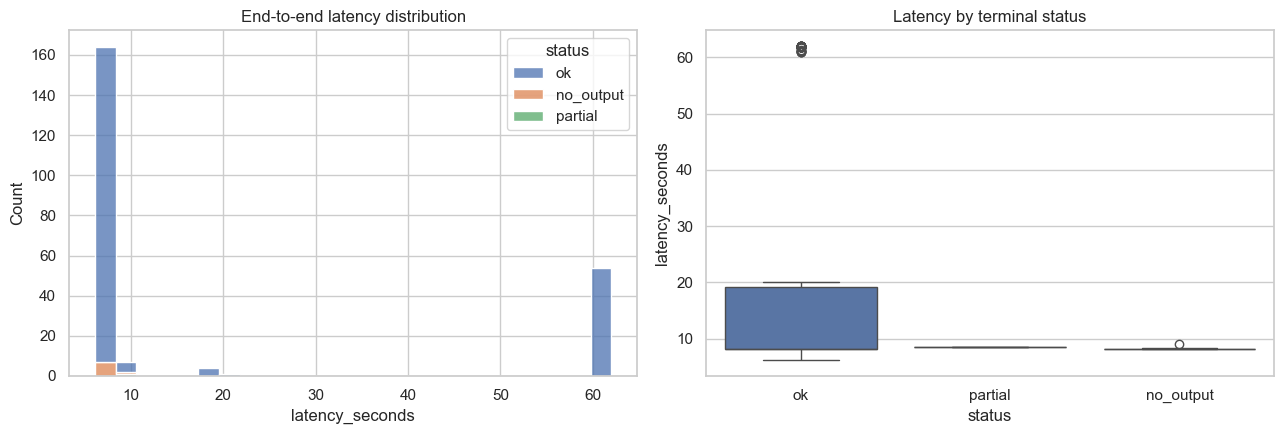

,completion,questions
0,partial_timeout,196
1,complete_output_captured,26
2,timeout_no_output,8


In [6]:
latency_metrics = df.groupby(['status','completion']).latency_seconds.agg(['count','mean','median','min','max']).reset_index()
display(latency_metrics.style.format({c:'{:.2f}' for c in ['mean','median','min','max']}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=df, x='latency_seconds', hue='status', bins=25, multiple='stack', ax=axes[0])
axes[0].set_title('End-to-end latency distribution')
sns.boxplot(data=df, x='status', y='latency_seconds', order=['ok','partial','no_output'], ax=axes[1])
axes[1].set_title('Latency by terminal status')
plt.tight_layout(); plt.show()

completion = df.completion.value_counts().rename_axis('completion').reset_index(name='questions')
display(completion)

## 6. Sequential behavior and endpoint change point

Rolling curves reveal whether failures are isolated or form a persistent run. A sustained serving outage must not be interpreted as a sudden model capability collapse.

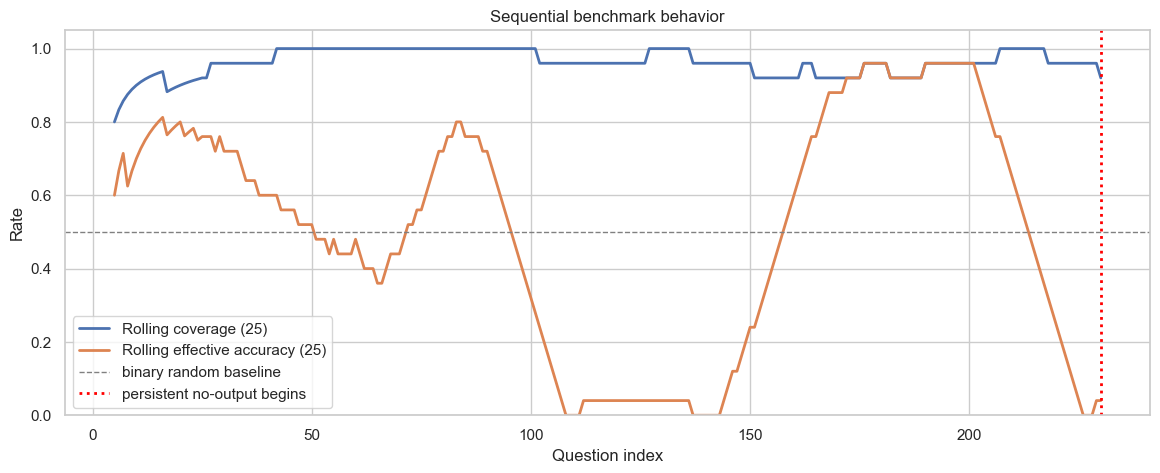

,start_question,end_question,length
0,2,2,1
1,17,17,1
2,102,102,1
3,137,137,1
4,151,151,1
5,165,165,1
6,182,182,1
7,218,218,1
8,230,230,1


In [7]:
window = 25
df = df.sort_values('question_index').copy()
df['rolling_coverage_25'] = df.has_answer.rolling(window, min_periods=5).mean()
df['rolling_effective_accuracy_25'] = df.correct.rolling(window, min_periods=5).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.question_index, df.rolling_coverage_25, label='Rolling coverage (25)', linewidth=2)
ax.plot(df.question_index, df.rolling_effective_accuracy_25, label='Rolling effective accuracy (25)', linewidth=2)
ax.axhline(.5, color='gray', linestyle='--', linewidth=1, label='binary random baseline')
ax.axvline(230, color='red', linestyle=':', linewidth=2, label='persistent no-output begins')
ax.set(ylim=(0,1.05), xlabel='Question index', ylabel='Rate', title='Sequential benchmark behavior')
ax.legend(loc='lower left'); plt.show()

# Find consecutive failure runs inside the pilot.
failure = ~df.has_answer
runs=[]; start=None
for idx, is_failure in zip(df.question_index, failure):
    if is_failure and start is None: start=idx
    if not is_failure and start is not None:
        runs.append((start, idx-1, idx-start)); start=None
if start is not None: runs.append((start, int(df.question_index.max()), int(df.question_index.max())-start+1))
run_df = pd.DataFrame(runs, columns=['start_question','end_question','length']).sort_values('length', ascending=False)
display(run_df.head(10))

## 7. Image-profile hypothesis audit

`close_up_proxy` is a heuristic based on foreground occupancy relative to border color. It is not a human-verified framing label, so this section is exploratory rather than causal evidence.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
image_profile.width,230.0,NaN,NaN,NaN,979.252174,59.681226,900.0,900.0,1024.0,1024.0,1024.0
image_profile.height,230.0,NaN,NaN,NaN,979.252174,59.681226,900.0,900.0,1024.0,1024.0,1024.0
image_profile.file_bytes,230.0,NaN,NaN,NaN,1051963.291304,388734.747883,488569.0,541765.5,1328095.5,1349717.5,1401074.0
image_profile.foreground_occupancy_proxy,230.0,NaN,NaN,NaN,0.640322,0.027439,0.5571,0.62575,0.64335,0.650275,0.7283
image_profile.close_up_proxy,230,2,True,209,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,image_profile.close_up_proxy,n,answered,coverage,conditional_accuracy,effective_accuracy,mean_latency_s
0,False,21,19,90.5%,31.6%,28.6%,8.16
1,True,209,202,96.7%,51.5%,49.8%,22.22


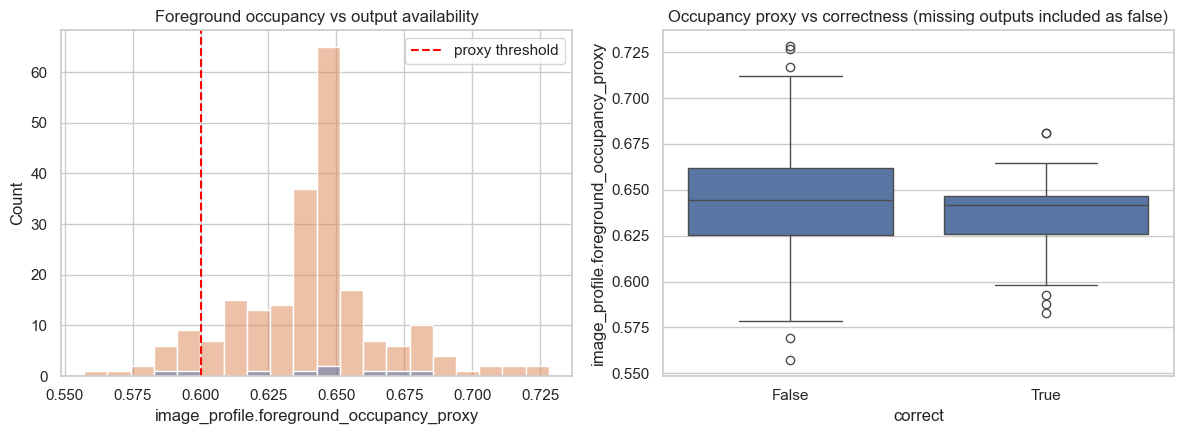

In [8]:
profile_cols = ['image_profile.width','image_profile.height','image_profile.file_bytes',
                'image_profile.foreground_occupancy_proxy','image_profile.close_up_proxy']
display(df[profile_cols].describe(include='all').T)

profile_metrics = slice_metrics(df, ['image_profile.close_up_proxy'])
display(profile_metrics.style.format({'coverage':'{:.1%}', 'conditional_accuracy':'{:.1%}',
                                      'effective_accuracy':'{:.1%}', 'mean_latency_s':'{:.2f}'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(data=df, x='image_profile.foreground_occupancy_proxy', hue='has_answer', bins=20, ax=axes[0])
axes[0].axvline(.6, color='red', linestyle='--', label='proxy threshold'); axes[0].legend()
axes[0].set_title('Foreground occupancy vs output availability')
sns.boxplot(data=df, x='correct', y='image_profile.foreground_occupancy_proxy', ax=axes[1])
axes[1].set_title('Occupancy proxy vs correctness (missing outputs included as false)')
plt.tight_layout(); plt.show()

## 8. Reasoning/output capture audit

Many early records were captured at timeout with a parseable final answer. They can support answer scoring, but reasoning completeness should not be assumed unless the structured completion marker was captured.

,completion,output_parse_format,questions,answered,median_reasoning_chars,median_response_chars
0,complete_output_captured,nvidia_ui,26,26,967.0,1.0
1,partial_timeout,answer_only,3,3,0.0,1.0
2,partial_timeout,nvidia_ui,192,192,1316.5,1.0
3,partial_timeout,unstructured,1,0,0.0,2346.0
4,timeout_no_output,empty,8,0,0.0,0.0


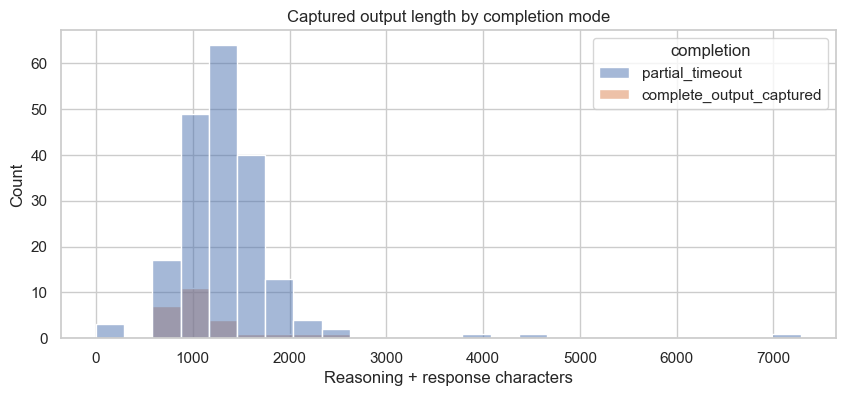

In [9]:
capture = df.groupby(['completion','output_parse_format'], dropna=False).agg(
    questions=('sample_id','size'), answered=('has_answer','sum'),
    median_reasoning_chars=('reasoning_chars','median'), median_response_chars=('response_chars','median')
).reset_index()
display(capture)

fig, ax = plt.subplots(figsize=(10,4))
answered_df = df[df.has_answer].copy()
sns.histplot(data=answered_df, x='answer_length', hue='completion', bins=25, ax=ax)
ax.set_title('Captured output length by completion mode'); ax.set_xlabel('Reasoning + response characters')
plt.show()

## 9. Automatic executive conclusion

The conclusions below are generated from the current checkpoint rather than manually typed scores.

In [10]:
bottle = category_metrics.loc[category_metrics.category.eq('bottle')].iloc[0]
cable = category_metrics.loc[category_metrics.category.eq('cable')].iloc[0]
normal = state_metrics.loc[state_metrics.is_normal.eq(True)].iloc[0]
anomalous = state_metrics.loc[state_metrics.is_normal.eq(False)].iloc[0]

conclusion = f'''### Executive findings

1. **Serving coverage is high inside the pilot but not reliable at scale.** {answered}/{n} questions produced a parsed answer ({coverage:.1%}). The runner then entered a persistent no-output state at question 230; later requests must be treated as an endpoint incident, not model errors.
2. **Overall discrimination is not demonstrated.** Conditional accuracy is {conditional_accuracy:.1%} ({correct}/{answered}), statistically consistent with the 50% binary random-choice baseline given the current confidence interval ({accuracy_ci[0]:.1%}–{accuracy_ci[1]:.1%}).
3. **Performance is strongly category-dependent.** Bottle accuracy is {bottle.conditional_accuracy:.1%} (n={int(bottle.answered)}), while cable accuracy is {cable.conditional_accuracy:.1%} (n={int(cable.answered)}).
4. **The main capability weakness is anomaly sensitivity.** Accuracy on normal images is {normal.conditional_accuracy:.1%}, versus {anomalous.conditional_accuracy:.1%} on anomalous images. This indicates a severe state-dependent failure and must be investigated with per-defect evidence.
5. **This segment is not representative of full MMAD.** It contains only {', '.join(sorted(df.category.unique()))} from {', '.join(sorted(df.source_dataset.unique()))}; no valid full-benchmark ranking against Qwen can be made.
6. **The close-up hypothesis remains unproven.** The current occupancy label is only a proxy and the groups are highly imbalanced. A balanced, human-audited framing experiment is required.

### Decision

Treat this run as a **serving-constrained pilot**. Preserve its {answered} parsed answers for exploratory analysis, but do not publish {effective_accuracy:.1%} as a Cosmos 3 full-MMAD score. The next valid experiment needs an authorized API/self-hosted endpoint, deterministic request logging, a held-out balanced sample across task types and categories, and explicit separation of model abstention from infrastructure failure.
'''
display(Markdown(conclusion))

### Executive findings

1. **Serving coverage is high inside the pilot but not reliable at scale.** 221/230 questions produced a parsed answer (96.1%). The runner then entered a persistent no-output state at question 230; later requests must be treated as an endpoint incident, not model errors.
2. **Overall discrimination is not demonstrated.** Conditional accuracy is 49.8% (110/221), statistically consistent with the 50% binary random-choice baseline given the current confidence interval (43.2%–56.3%).
3. **Performance is strongly category-dependent.** Bottle accuracy is 66.7% (n=81), while cable accuracy is 40.0% (n=140).
4. **The main capability weakness is anomaly sensitivity.** Accuracy on normal images is 97.3%, versus 25.3% on anomalous images. This indicates a severe state-dependent failure and must be investigated with per-defect evidence.
5. **This segment is not representative of full MMAD.** It contains only bottle, cable from MVTec-AD; no valid full-benchmark ranking against Qwen can be made.
6. **The close-up hypothesis remains unproven.** The current occupancy label is only a proxy and the groups are highly imbalanced. A balanced, human-audited framing experiment is required.

### Decision

Treat this run as a **serving-constrained pilot**. Preserve its 221 parsed answers for exploratory analysis, but do not publish 47.8% as a Cosmos 3 full-MMAD score. The next valid experiment needs an authorized API/self-hosted endpoint, deterministic request logging, a held-out balanced sample across task types and categories, and explicit separation of model abstention from infrastructure failure.


## Reproducibility notes

- Input checkpoint: `research/mmad_model_benchmark/outputs/cosmos3_full/predictions.jsonl`
- Scope: latest record for `mmad_full_00001` through `mmad_full_00230`
- Model: `nvidia/cosmos3-nano-reasoner`
- Backend: NVIDIA Build Experience UI
- Benchmark manifest is asserted to be unique.
- No result after question 230 is included.
- The notebook contains no credentials, API keys or uploaded images.